In [1]:
import os, sys
import yaml
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('graph.py'))
from graph import *

pmfPathTemp = "data/<pair>/pmf-<method>.dat"
diffPathTemp = "data/<pair>/diff-<method>.dat"
ymlPathTemp = "data/<pair>/about.yml"
imgPath = '/Users/yasmene/Library/CloudStorage/OneDrive-Personal/UW research/gb-star/GBStar images/'
def temp2path(template, pair, method):
    return template.replace('<pair>', pair['name']).replace('<method>', method)

import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 2.0



In [2]:
dirList = os.listdir('data/')
pairList = [pair for pair in dirList if "-" in pair]
print(pairList)


['dma-na', 'ace-ace', 'na-ca', 'ace-ca', 'ace-dma', 'na-na', 'ca-cl', 'ace-na', 'dma-ca', 'na-cl', 'dma-dma', 'ace-cl', 'ca-ca', 'dma-cl', 'cl-cl']


In [3]:
# Load pair info
pair = {'name': pairList[3]}

with open(temp2path(ymlPathTemp, pair, '')) as stream:
    pairInfo = yaml.safe_load(stream)
qprod = pairInfo['A']['charge'] * pairInfo['B']['charge']

sysTitle = pairInfo['A']['name'] + " -- " + pairInfo['B']['name']
print("System:", sysTitle, "q1*q2 = ", qprod)

# Load PMF data
for method in ['gb', 'mm', 'dft', 'gbx', 'gbxx', 'mmx']:
    if pairInfo[method] == None: print("No data for", method); continue
    pmfData = loadPMF(temp2path(pmfPathTemp, pair, method))
    pairInfo[method]['pmfData'] = pmfData
# Load diff data
for method in ['gbx', 'gbxx', 'mmx']:
    if pairInfo[method] == None: print("No data for", method); continue
    diffData = loadPMF(temp2path(diffPathTemp, pair, method))
    pairInfo[method]['diffData'] = diffData


System: Acetate -- Calcium q1*q2 =  -2
Loaded: data/ace-ca/pmf-gb.dat
Loaded: data/ace-ca/pmf-mm.dat
Loaded: data/ace-ca/pmf-dft.dat
Loaded: data/ace-ca/pmf-gbx.dat
Loaded: data/ace-ca/pmf-gbxx.dat
Loaded: data/ace-ca/pmf-mmx.dat
Loaded: data/ace-ca/diff-gbx.dat
Loaded: data/ace-ca/diff-gbxx.dat
Loaded: data/ace-ca/diff-mmx.dat


(0.2, 1.2)

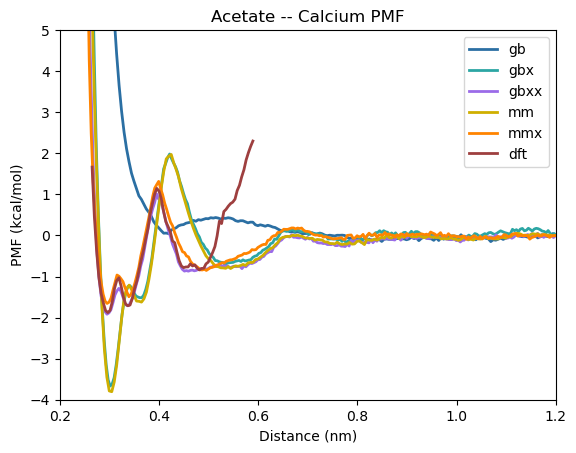

In [4]:
# graph pmfs
for method in ['gb', 'gbx', 'gbxx', 'mm', 'mmx', 'dft']:
    if pairInfo[method] == None: print("No data for", method); continue
    pmfData = pairInfo[method]['pmfData']
    plt.plot(pmfData[:,0], pmfData[:,1], label=method, color=colorDic[method])
plt.title(sysTitle + " PMF")
plt.xlabel("Distance (nm)")
plt.ylabel("PMF (kcal/mol)")
plt.legend()
plt.ylim(-4, 5)
plt.xlim(0.2,1.2)

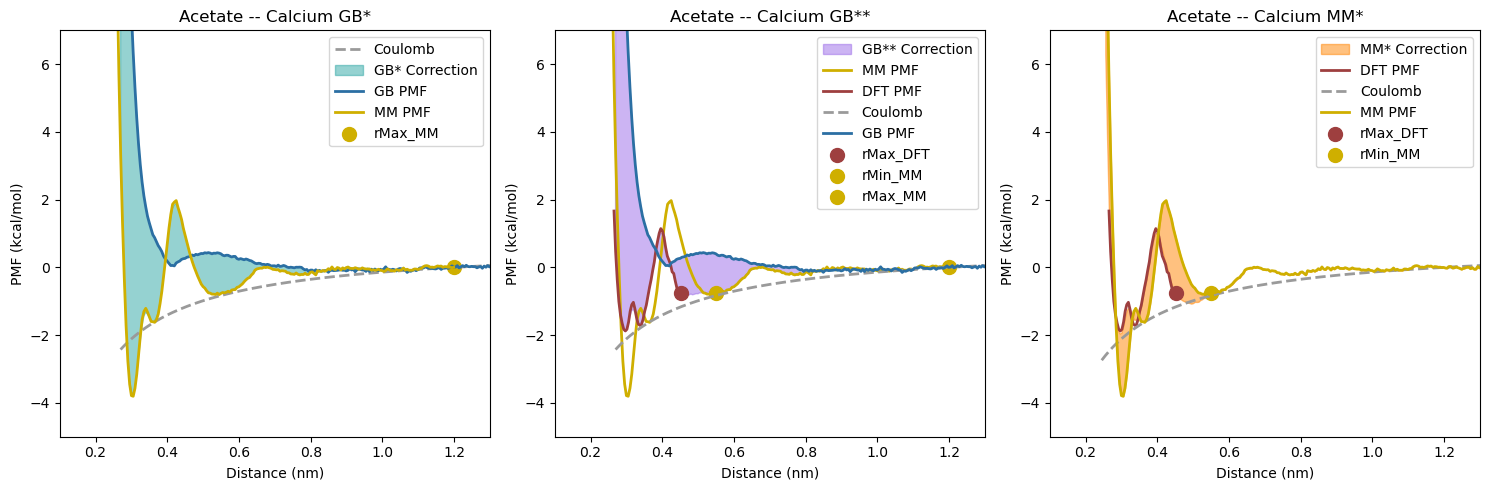

In [5]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
graphGBX(pairInfo)

plt.subplot(1, 3, 2)
graphGBXX(pairInfo)

plt.subplot(1, 3, 3)
graphMMX(pairInfo)

plt.tight_layout()
plt.show()



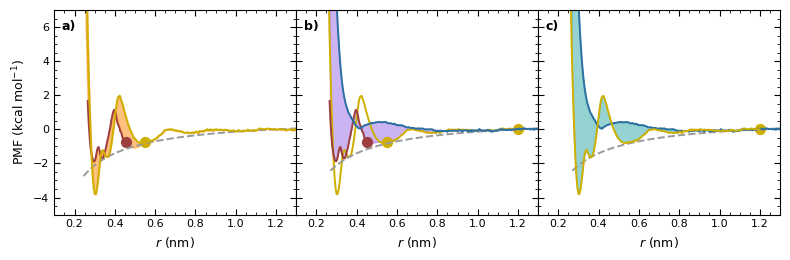

In [ ]:
fig, axs = graphCorrectionPanels(
    pairInfo
)

for ax, panel_label in zip(axs, ["a)", "b)", "c)"]):
    ax.text(
        0.03, 0.95,
        panel_label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        fontweight="bold",
    )

fig.savefig(f'{imgPath}/{pair["name"]}_panel_plot.pdf', format="pdf", bbox_inches="tight")

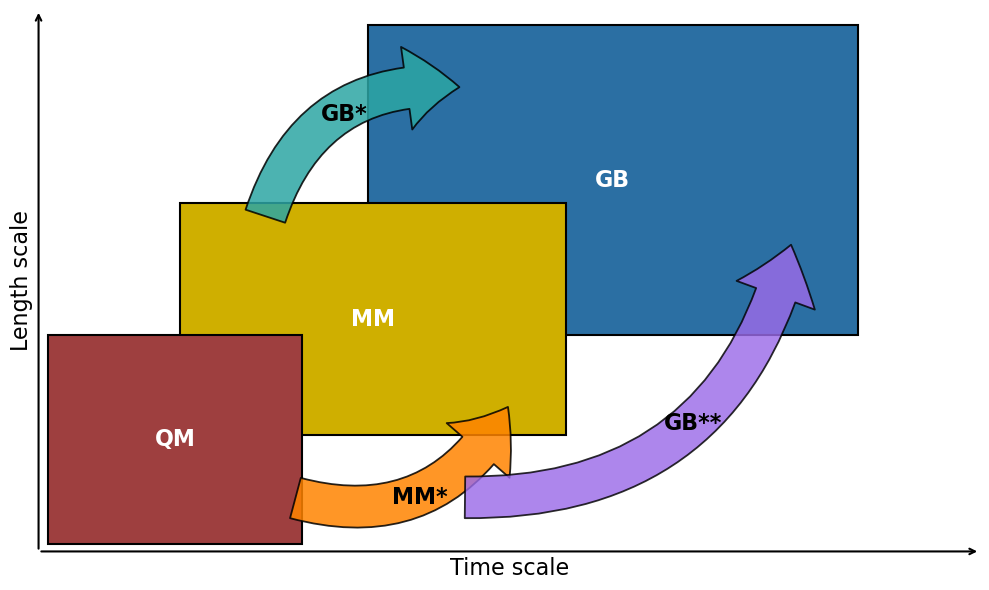

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch


# -----------------------------
# Color palette
# -----------------------------
# colorDic = {
#     'coulomb': '#8A8A8A',

#     # base model blocks
#     'gb':      '#005A8D',
#     'mm':      '#B87500',
#     'dft':     '#7A3326',

#     # correction / transition arrows
#     'gbx':     '#71B7E6',
#     'gbxx':    '#C38BB8',
#     'mmx':     '#E8BD6D',
# }

textColorDic = {
    'gb': 'white',
    'mm': 'white',
    'dft': 'white',
    'gbx': 'black',
    'gbxx': 'black',
    'mmx': 'black',
}


# -----------------------------
# Helper functions
# -----------------------------
def add_box(ax, xy, width, height, label, key, zorder=2, fontsize=16):
    """Add a labeled model box."""
    rect = Rectangle(
        xy,
        width,
        height,
        facecolor=colorDic[key],
        edgecolor='black',
        linewidth=1.5,
        alpha=1.0,
        zorder=zorder
    )
    ax.add_patch(rect)

    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        label,
        ha='center',
        va='center',
        fontsize=fontsize,
        fontweight='bold',
        color=textColorDic.get(key, 'black'),
        zorder=zorder + 0.1
    )


def add_curved_arrow(
    ax,
    start,
    end,
    key,
    label=None,
    rad=0.45,
    alpha=0.85,
    text_offset=(0, 0),
    fontsize=16,
    zorder=10,
    head_width=28,
    head_length=34,
    tail_width=16,
):
    """Add a thick curved arrow with optional label."""
    arrow = FancyArrowPatch(
        start,
        end,
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle=(
            f"Simple,"
            f"head_width={head_width},"
            f"head_length={head_length},"
            f"tail_width={tail_width}"
        ),
        facecolor=colorDic[key],
        edgecolor='black',
        linewidth=1.3,
        alpha=alpha,
        zorder=zorder
    )
    ax.add_patch(arrow)

    if label is not None:
        xm = (start[0] + end[0]) / 2 + text_offset[0]
        ym = (start[1] + end[1]) / 2 + text_offset[1]
        ax.text(
            xm,
            ym,
            label,
            ha='center',
            va='center',
            fontsize=fontsize,
            fontweight='bold',
            color=textColorDic.get(key, 'black'),
            zorder=zorder + 1
        )


# -----------------------------
# Make diagram
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(0, 10)
ax.set_ylim(0, 7)

# -----------------------------
# Base model blocks
# Lower zorder = farther back
# GB bottom, MM middle, QM/DFT top
# -----------------------------
add_box(
    ax,
    xy=(3.5, 2.8),
    width=5.2,
    height=4.0,
    label='GB',
    key='gb',
    zorder=2
)

add_box(
    ax,
    xy=(1.5, 1.5),
    width=4.1,
    height=3.0,
    label='MM',
    key='mm',
    zorder=3
)

add_box(
    ax,
    xy=(0.1, 0.1),
    width=2.7,
    height=2.7,
    label='QM',
    key='dft',
    zorder=4
)


# -----------------------------
# Large correction arrows
# Arrows sit above all boxes
# -----------------------------

# MM* arrow: from QM/DFT to MM, curving outward
add_curved_arrow(
    ax,
    start=(2.7, 0.7),
    end=(5, 1.9),
    key='mmx',
    label='MM*',
    rad=0.4,
    alpha=0.85,
    text_offset=(0.2, -0.6),
    zorder=10,
    head_width=60,
    head_length=38,
    tail_width=30,
)

# GB* arrow: from MM to GB, curving outward above
add_curved_arrow(
    ax,
    start=(2.4, 4.3),
    end=(4.5, 6),
    key='gbx',
    label='GB*',
    rad=-0.4,
    alpha=0.85,
    text_offset=(-0.2, 0.5),
    zorder=11,
    head_width=60,
    head_length=38,
    tail_width=30,
)

# GB** branch: branches from MM* path and continues to GB
add_curved_arrow(
    ax,
    start=(4.5, 0.7),
    end=(8, 4),
    key='gbxx',
    label='GB**',
    rad=0.4,
    alpha=0.82,
    text_offset=(0.7, -0.7),
    zorder=12,
    head_width=60,
    head_length=38,
    tail_width=30,
)


# -----------------------------
# Axis labels and styling
# -----------------------------
ax.set_xlabel('Time scale', fontsize=16)
ax.set_ylabel('Length scale', fontsize=16)

ax.set_xticks([])
ax.set_yticks([])

ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

ax.annotate(
    '',
    xy=(10, 0),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', linewidth=1.5, color='black')
)

ax.annotate(
    '',
    xy=(0, 7),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', linewidth=1.5, color='black')
)

plt.tight_layout()
plt.show()